# EMS741 Reptile – Load From Checkpoint and Evaluate

This notebook assumes you already trained a meta-model and have a checkpoint like `checkpoints/meta_iter_150.pt` in the same workspace. It reloads the model, runs few-shot evaluation, and produces qualitative images.

## 1. Environment and data

In [3]:
# CELL 1 - FIX OMP CONFLICT FIRST
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
print("✅ OpenMP conflict fixed")

!nvidia-smi -L || echo 'No GPU visible (CPU only)'

✅ OpenMP conflict fixed
'No GPU visible (CPU only)'


'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import os, zipfile, urllib.request, glob, random, json, csv, copy
from datetime import datetime

import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

DATA_URL = 'https://zenodo.org/records/18745413/files/ems741_cw_data.zip?download=1'
ZIP_PATH = 'data.zip'
if not os.path.exists(ZIP_PATH):
    print('Downloading data...')
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    print('Download complete')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall('./')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 2. Tasks and in-memory datasets

In [5]:
TRAIN_ROOT, VAL_ROOT, TEST_ROOT = './train', './val', './test'

def list_tasks(root):
    return sorted([os.path.join(root, d) for d in os.listdir(root) if d.startswith('task_')])

train_tasks = list_tasks(TRAIN_ROOT)
val_tasks   = list_tasks(VAL_ROOT)
test_tasks  = list_tasks(TEST_ROOT)

print('Train tasks:', train_tasks)
print('Val tasks  :', val_tasks)
print('Test tasks :', test_tasks)

class SliceDataset(Dataset):
    def __init__(self, task_root, min_mask_sum=1.0):
        img_dir = os.path.join(task_root, 'images')
        msk_dir = os.path.join(task_root, 'masks')
        img_files = sorted(glob.glob(os.path.join(img_dir, '*.png')))
        msk_files = sorted(glob.glob(os.path.join(msk_dir, '*.png')))
        self.cached = []
        for ip, mp in zip(img_files, msk_files):
            m = np.array(Image.open(mp), dtype=np.float32)
            if m.max() > 1: m = m / 255.0
            if m.sum() >= min_mask_sum:
                img = np.array(Image.open(ip), dtype=np.float32)
                if img.max() > 1: img = img / 255.0
                img = torch.from_numpy(img).float().unsqueeze(0)
                msk = torch.from_numpy(m).float().unsqueeze(0)
                self.cached.append((img, msk))
    def __len__(self):
        return len(self.cached)
    def __getitem__(self, idx):
        return self.cached[idx]

print('Pre-loading slices into RAM...')
cached_datasets = {}
for split, task_list in [('train', train_tasks), ('val', val_tasks), ('test', test_tasks)]:
    for t in tqdm(task_list, desc=f'Loading {split}'):
        cached_datasets[t] = SliceDataset(t, min_mask_sum=1.0)
print('Loaded datasets for', len(cached_datasets), 'tasks')

Train tasks: ['./train\\task_2', './train\\task_3', './train\\task_5', './train\\task_7']
Val tasks  : ['./val\\task_4', './val\\task_6']
Test tasks : ['./test\\task_1', './test\\task_8']
Pre-loading slices into RAM...


Loading train:   0%|          | 0/4 [00:00<?, ?it/s]

Loading val:   0%|          | 0/2 [00:00<?, ?it/s]

Loading test:   0%|          | 0/2 [00:00<?, ?it/s]

Loaded datasets for 8 tasks


## 3. Simple U-Net model

In [6]:
class SimpleUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.c1a = nn.Conv2d(in_channels, 32, 3, padding=1)
        self.c1b = nn.Conv2d(32, 32, 3, padding=1)
        self.p1 = nn.MaxPool2d(2)
        self.c2a = nn.Conv2d(32, 64, 3, padding=1)
        self.c2b = nn.Conv2d(64, 64, 3, padding=1)
        self.p2 = nn.MaxPool2d(2)
        self.c3a = nn.Conv2d(64, 128, 3, padding=1)
        self.c3b = nn.Conv2d(128, 128, 3, padding=1)
        self.p3 = nn.MaxPool2d(2)
        self.c4a = nn.Conv2d(128, 256, 3, padding=1)
        self.c4b = nn.Conv2d(256, 256, 3, padding=1)
        self.up1 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u1a = nn.Conv2d(256 + 128, 128, 3, padding=1)
        self.u1b = nn.Conv2d(128, 128, 3, padding=1)
        self.up2 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u2a = nn.Conv2d(128 + 64, 64, 3, padding=1)
        self.u2b = nn.Conv2d(64, 64, 3, padding=1)
        self.up3 = nn.Upsample(scale_factor=2, mode='nearest')
        self.u3a = nn.Conv2d(64 + 32, 32, 3, padding=1)
        self.u3b = nn.Conv2d(32, 32, 3, padding=1)
        self.out = nn.Conv2d(32, out_channels, 1)
        self.act = nn.ReLU(inplace=True)
        self.final = nn.Sigmoid()
    def forward(self, x):
        x1 = self.act(self.c1b(self.act(self.c1a(x)))); p1 = self.p1(x1)
        x2 = self.act(self.c2b(self.act(self.c2a(p1)))); p2 = self.p2(x2)
        x3 = self.act(self.c3b(self.act(self.c3a(p2)))); p3 = self.p3(x3)
        b  = self.act(self.c4b(self.act(self.c4a(p3))))
        y = self.up1(b); y = torch.cat([y, x3], dim=1); y = self.act(self.u1b(self.act(self.u1a(y))))
        y = self.up2(y); y = torch.cat([y, x2], dim=1); y = self.act(self.u2b(self.act(self.u2a(y))))
        y = self.up3(y); y = torch.cat([y, x1], dim=1); y = self.act(self.u3b(self.act(self.u3a(y))))
        return self.final(self.out(y))

## 4. Losses and metrics

In [7]:
def soft_dice_loss(pred, target, eps=1e-6):
    inter = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
    dice = (2 * inter + eps) / (union + eps)
    return 1.0 - dice.mean()

def dice_score(pred, target, eps=1e-6):
    p = (pred > 0.5).float(); t = target.float()
    inter = (p * t).sum(dim=(1,2,3)); union = p.sum(dim=(1,2,3)) + t.sum(dim=(1,2,3))
    return ((2 * inter + eps) / (union + eps)).mean().item()

Check for checkpoint

In [8]:
import os
checkpoint_path = 'checkpoints/meta_iter_125.pt'  # adjust path if needed

print("=== CHECKPOINT DIAGNOSTIC ===")
print(f"Working directory: {os.getcwd()}")
print(f"checkpoints/ exists: {os.path.exists('checkpoints')}")
print(f"Full path exists: {os.path.exists(checkpoint_path)}")

if os.path.exists(checkpoint_path):
    file_size = os.path.getsize(checkpoint_path)
    print(f"File size: {file_size} bytes ({file_size/1024/1024:.1f} MB)")
    
    try:
        import torch
        ckpt = torch.load(checkpoint_path, map_location='cpu')
        print("✅ torch.load succeeded!")
        print("Checkpoint keys:", list(ckpt.keys()))
        print("Has 'model_state'?", 'model_state' in ckpt)
        if 'model_state' in ckpt:
            print("model_state keys (first 5):", list(ckpt['model_state'].keys())[:5])
    except Exception as e:
        print("❌ torch.load FAILED:", str(e))
else:
    print("❌ File not found. Check your folder structure.")

=== CHECKPOINT DIAGNOSTIC ===
Working directory: c:\Git\EMS741U-Group8\QMUL-EMS741-Group-8
checkpoints/ exists: True
Full path exists: True
File size: 7796449 bytes (7.4 MB)
✅ torch.load succeeded!
Checkpoint keys: ['model_state', 'meta_loss_history', 'iter']
Has 'model_state'? True
model_state keys (first 5): ['c1a.weight', 'c1a.bias', 'c1b.weight', 'c1b.bias', 'c2a.weight']


## 5. Load meta-learned checkpoint

In [9]:
# FIXED CELL 5 - SAFE LOAD
checkpoint_path = 'checkpoints/meta_iter_125.pt'

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

ckpt = torch.load(checkpoint_path, map_location='cpu')
print(f"Loaded {checkpoint_path}")
print(f"Iteration: {ckpt.get('iter', 'unknown')}")

meta_model = SimpleUNet(in_channels=1, out_channels=1)
meta_model.load_state_dict(ckpt['model_state'])
meta_model.to(device).eval()

print("✅ Model ready for evaluation!")

Loaded checkpoints/meta_iter_125.pt
Iteration: 124
✅ Model ready for evaluation!


## 6. Few-shot evaluation with qualitative images

Running qualitative evaluation on first few val tasks...
Task task_4 | 1-shot Dice: 0.0381


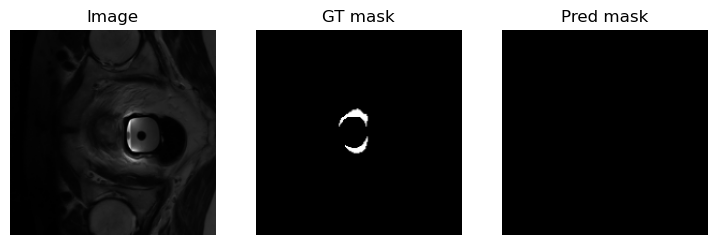

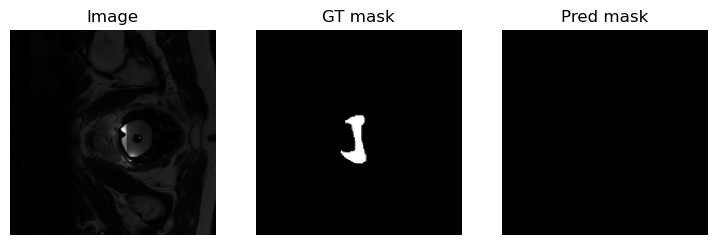

Task task_4 | 3-shot Dice: 0.0380


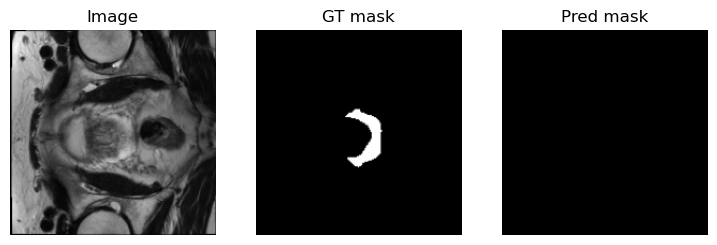

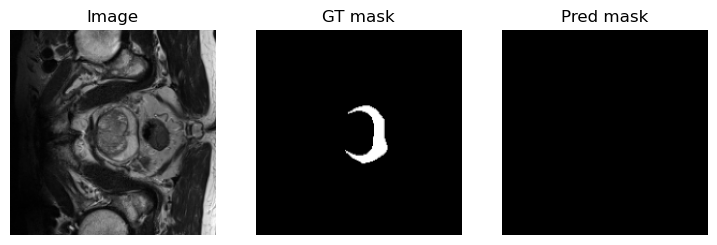

Task task_4 | 5-shot Dice: 0.0380


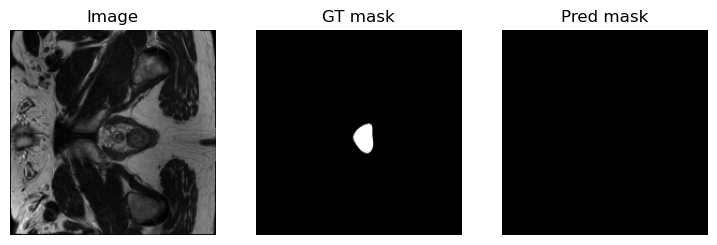

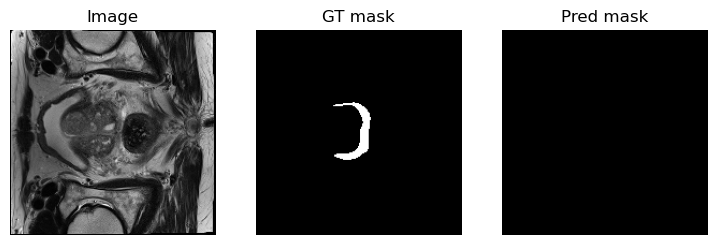

In [ ]:
def eval_task_with_images(model, task_root, shots=4, steps=10, lr_inner=1e-3, device=device, n_vis=3):
    ds = cached_datasets[task_root]
    n = len(ds)
    if n <= shots:
        raise ValueError(f'Not enough slices in {task_root}')
    idxs = np.random.permutation(n)
    xs, ys = zip(*[ds[i] for i in idxs[:shots]])
    xq, yq = zip(*[ds[i] for i in idxs[shots:]])
    xs, ys = torch.stack(xs).to(device), torch.stack(ys).to(device)
    xq, yq = torch.stack(xq).to(device), torch.stack(yq).to(device)
    adapted = copy.deepcopy(model).to(device)
    opt = torch.optim.SGD(adapted.parameters(), lr=lr_inner)
    for _ in range(steps):
        opt.zero_grad()
        out_s = adapted(xs)
        if out_s.shape != ys.shape: ys = ys.view_as(out_s)
        loss = F.binary_cross_entropy(out_s, ys) + soft_dice_loss(out_s, ys)
        loss.backward()
        opt.step()
    with torch.no_grad():
        out_q = adapted(xq)
    d = dice_score(out_q.cpu(), yq.cpu())
    print(f'Task {os.path.basename(task_root)} | {shots}-shot Dice: {d:.4f}')
    k = min(n_vis, xq.shape[0])
    for i in range(k):
        img = xq[i,0].cpu().numpy()
        gt  = yq[i,0].cpu().numpy()
        pr  = (out_q[i,0].cpu().numpy() > 0.5).astype(float)
        fig, axs = plt.subplots(1,3,figsize=(9,3))
        axs[0].imshow(img, cmap='gray'); axs[0].set_title('Image'); axs[0].axis('off')
        axs[1].imshow(gt, cmap='gray'); axs[1].set_title('GT mask'); axs[1].axis('off')
        axs[2].imshow(pr, cmap='gray'); axs[2].set_title('Pred mask'); axs[2].axis('off')
        plt.show()
    return d

print('Running qualitative evaluation on first few val tasks...')
for t in val_tasks[:2]:
    for s in [1, 3, 5]:
        eval_task_with_images(meta_model, t, shots=s, steps=10, lr_inner=1e-3, device=device, n_vis=2)